# Point-E Preprocessing Pipeline: Phase 1 (2D Square Cropping)

Visually verify 2D transformations.

Point-E's image conditions (using CLIP) require standard square images. If we simply resize rectangular crops, the geometry will stretch, causing misalignment between the 2D view and the real 3D point cloud logic later.

So use square cropping that finds the pothole, forces the bounding box into a 1:1 ratio based on the largest dimension, adds an asphalt context margin, and applies zero-padding (black edges) if the crop hits the boundaries.

In [1]:
import sys
import cv2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import open3d as o3d

# Setup paths
candidate_roots = [d for d in Path.cwd().parents if d.name == "multimodal-pothole-detection"]
if len(candidate_roots) == 0:
    if Path.cwd().name == "multimodal-pothole-detection":
        code_root = Path.cwd()
    else:
        raise RuntimeError("Notebook needs to be run within the multimodal-pothole-detection project.")
else:
    code_root = candidate_roots[-1]

scripts_root = code_root / "src" / "scripts"
print(f"Code Root: {code_root}")
if str(scripts_root) not in sys.path:
    sys.path.insert(0, str(scripts_root))

from pothole_geometry import load_yolo_mask
from point_e_pipeline_utils import get_square_bbox_from_mask, apply_square_crop, compute_leveled_point_cloud, format_point_e_tensor

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
Code Root: c:\Users\AdriBom\Documents\Repos\dgm-2026.1\projects\multimodal-pothole-detection


In [2]:
# 1. Configuration and Data Loading
CONTEXT_MARGIN_PX = 20  # Additional pixels to include around the pothole

dataset_root = code_root / "data" / "raw" / "PothRGDB" / "PUBLIC POTHOLE DATASET"
manifest = pd.read_csv(code_root / "data" / "interim" / "pothrgbd_manifest.csv")
valid_samples = manifest[manifest["status"] == "ok"].reset_index(drop=True)

# Select sample to visualize
sample_idx = 300
row = valid_samples.iloc[sample_idx]
print(f"Loaded Sample ID: {row['sample_id']}")

rgb_path = dataset_root / row["image_path"]
mask_path = dataset_root / row["label_path"]

# Load
rgb_img = cv2.cvtColor(cv2.imread(str(rgb_path)), cv2.COLOR_BGR2RGB)
mask_img = load_yolo_mask(mask_path, image_shape=rgb_img.shape[:2])

Loaded Sample ID: 20250305_042445


## Visual Verification: Original vs Safe Square Crop
We want to prove that our utility strictly preserves aspect ratios instead of stretching the image.

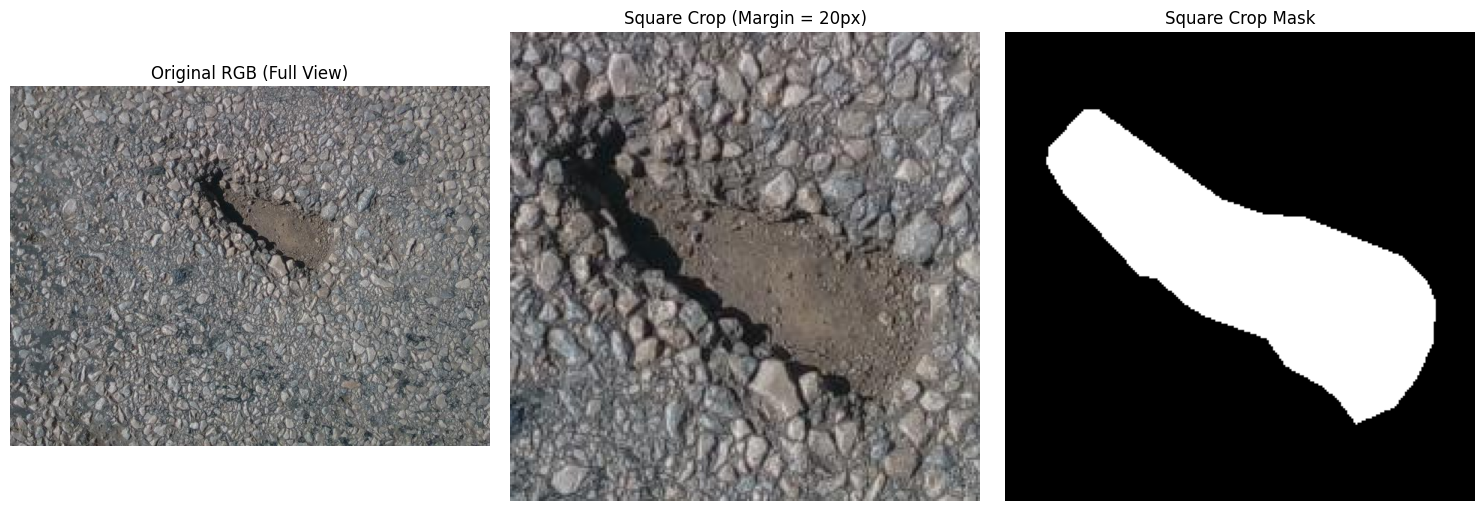

Original Shape: (480, 640, 3)
Cropped Shape: (228, 228, 3)


In [3]:
# Calculate the fixed square coordinates from the mask
square_bbox = get_square_bbox_from_mask(mask_img, margin_px=CONTEXT_MARGIN_PX)

# Apply that exact square bbox to both the RGB and the Mask
rgb_crop = apply_square_crop(rgb_img, square_bbox)
mask_crop = apply_square_crop(mask_img, square_bbox)

# Display Comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(rgb_img)
axes[0].set_title("Original RGB (Full View)")
axes[0].axis("off")

axes[1].imshow(rgb_crop)
axes[1].set_title(f"Square Crop (Margin = {CONTEXT_MARGIN_PX}px)")
axes[1].axis("off")

axes[2].imshow(mask_crop, cmap='gray')
axes[2].set_title("Square Crop Mask")
axes[2].axis("off")

plt.tight_layout()
plt.show()

print(f"Original Shape: {rgb_img.shape}")
print(f"Cropped Shape: {rgb_crop.shape}")

## 3D Geometry and Point-E Tensor Standardization
Now we extract the 3D points *only* from the unpadded valid region of our crop.
We ensure that the asphalt is completely leveled using RANSAC.
Finally, we apply Open3D's **Farthest Point Sampling** to grab exactly 1024 points, and uniformly scale $X, Y, Z$ into the rigid $[-1, 1]$ bounding box required by Point-E.

In [4]:
depth_path = dataset_root / row["depth_path"]
depth_img = np.load(depth_path)  # CRITICAL: `.npy` preserves exact millimeter physics

# Intrinsics
fx, fy = 460.0, 460.0
cx, cy = rgb_img.shape[1] / 2.0, rgb_img.shape[0] / 2.0

# 1. 3D Extraction + RANSAC Leveling
points_3d, colors_3d = compute_leveled_point_cloud(
    rgb_img=rgb_img,
    depth_img=depth_img,
    mask_img=mask_img,
    square_bbox=square_bbox,
    fx=fx, fy=fy, cx=cx, cy=cy
)
print(f"Raw Crop yielded {points_3d.shape[0]} points.")

# 2. Strict Point-E Sampling & Normalization
tensor_6d, scale_factor = format_point_e_tensor(points_3d, colors_3d, num_points=1024)

print("\n--- Point-E Ready Tensor ---")
print(f"Shape: {tensor_6d.shape}")
print(f"Global Scale Factor saved: {scale_factor:.2f} mm")

# Verify constraints
spatial = tensor_6d[:, :3]
color = tensor_6d[:, 3:]

print(f"\nConstraint Check (MUST be between -1.0 and 1.0):")
print(f"X range: {spatial[:, 0].min():.2f} to {spatial[:, 0].max():.2f}")
print(f"Y range: {spatial[:, 1].min():.2f} to {spatial[:, 1].max():.2f}")
print(f"Z range: {spatial[:, 2].min():.2f} to {spatial[:, 2].max():.2f}")
print(f"Color ranges: R({color[:, 0].min():.2f} to {color[:, 0].max():.2f}), G({color[:, 1].min():.2f} to {color[:, 1].max():.2f})")

Raw Crop yielded 49163 points.

--- Point-E Ready Tensor ---
Shape: (1024, 6)
Global Scale Factor saved: 127.13 mm

Constraint Check (MUST be between -1.0 and 1.0):
X range: -0.99 to 0.97
Y range: -0.95 to 1.00
Z range: -0.03 to 0.22
Color ranges: R(-0.91 to 0.59), G(-0.91 to 0.58)


In [5]:
# Vizualize the resulting AI Ready Tensor!

# Recreate Open3D PC just for visualization
pcd_ai = o3d.geometry.PointCloud()
pcd_ai.points = o3d.utility.Vector3dVector(spatial)
# Bring colors back from [-1, 1] to [0, 1] purely for open3d plotting
pcd_ai.colors = o3d.utility.Vector3dVector((color + 1.0) / 2.0)

# The view should look like a correctly angled pothole crater composed of exactly 1024 dots
o3d.visualization.draw_geometries([pcd_ai])